In [1]:
# ------------------ IMPORT LIBRARIES ------------------
import pandas as pd
import numpy as np
import re
import nltk
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ------------------ SETUP ------------------
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## load data

In [130]:

df = pd.read_csv("yelp restaurent data.csv")

In [131]:
df

,review_id,user_id,business_id,stars_x,useful,funny,cool,text,date,name,...,RestaurantsCounterService,AgesAllowed,DietaryRestrictions,generalized_category,total_weekly_hours,is_open_late,opens_early,is_open_24_7,review_length,review_year
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,...,Nil,Nil,Nil,Cafe/Coffee Shop,52.50,False,True,False,101,2018
1,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,...,Nil,Nil,Nil,General Restaurant,62.00,True,False,False,40,2015
2,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,...,Nil,Nil,Nil,Bar/Pub,6.25,True,True,False,94,2017
3,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3.0,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06,Hibachi Steak House & Sushi Bar,...,Nil,Nil,Nil,Japanese Restaurant,0.00,True,True,False,97,2016
4,lUUhg8ltDsUZ9h0xnwY4Dg,RreNy--tOmXMl1en0wiBOg,cPepkJeRMtHapc_b2Oe_dw,4.0,1,0,1,I was really between 3 and 4 stars for this on...,2018-07-17 03:30:07,Naked Tchopstix Express,...,Nil,Nil,Nil,Japanese Restaurant,69.00,False,False,False,313,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932821,PVRvzY0NxSU-fiK3JOXX7w,cTozFTTWjlFYc3yusdbZmA,uMVOtr16r1ELu46pWr4HCQ,1.0,0,0,0,Just average Thai food tonight. Bangkok has al...,2022-01-18 06:42:59,Bangkok Cuisine,...,Nil,Nil,Nil,Asian Fusion Restaurant,55.00,True,True,False,155,2022
1932822,cACxcUY_AIsQKkpDRXuqnw,MCzlzlOw7IGbRAKVjJBPtg,fcGexL5VH5G2Xw0tRj9uOQ,3.0,1,1,0,This is a good pizza option - they deliver thr...,2018-03-13 13:54:48,Slice,...,Nil,Nil,Nil,General Restaurant,92.00,True,False,False,153,2018
1932823,wD5ZWao_vjyT2h4xmGam8Q,7L7GL5Pi2cf8mbm2Dpw4zw,e_E-jq9mwm7wk75k7Yi-Xw,5.0,1,0,1,It is very rare for a restaurant to be this go...,2022-01-17 22:36:01,Lark,...,Nil,Nil,Nil,Bar/Pub,25.00,True,False,False,63,2022
1932824,YVX1Wsa4LYxjvFwuHBb_gA,RKPkxOYQlM0BjhM-H6_vAw,X4mouE_cMiwbfyCPZ_K-FA,4.0,3,0,2,"Good, maybe very good. I went for lunch, so t...",2015-01-23 23:52:03,Marhaba,...,Nil,Nil,Nil,General Restaurant,46.00,True,True,False,501,2015


 ## EARLY REVIEW AGGREGATION

In [133]:

df = df.sort_values(['business_id', 'date'])
early_reviews = df.groupby('business_id').head(20)  # First 5 reviews per business

# Aggregation logic
aggregation = {}
for col in early_reviews.columns:
    if col == 'text':
        aggregation[col] = lambda x: " ".join(x.astype(str))
    elif col == 'stars':
        aggregation[col] = 'mean'
    elif col in ['useful', 'funny', 'cool']:
        aggregation[col] = 'sum'
    elif col == 'date':
        aggregation[col] = 'min'
    elif col == 'business_id':
        continue
    else:
        aggregation[col] = 'first'

df = early_reviews.groupby('business_id').agg(aggregation).reset_index()


In [134]:
print(df.columns)


Index(['business_id', 'review_id', 'user_id', 'stars_x', 'useful', 'funny',
       'cool', 'text', 'date', 'name', 'address', 'city', 'state',
       'postal_code', 'latitude', 'longitude', 'stars_y', 'review_count',
       'is_open', 'categories', 'hours', 'ByAppointmentOnly',
       'BusinessAcceptsCreditCards', 'BikeParking', 'RestaurantsPriceRange2',
       'CoatCheck', 'RestaurantsTakeOut', 'RestaurantsDelivery', 'Caters',
       'WiFi', 'BusinessParking', 'WheelchairAccessible', 'HappyHour',
       'OutdoorSeating', 'HasTV', 'RestaurantsReservations', 'DogsAllowed',
       'Alcohol', 'GoodForKids', 'RestaurantsAttire', 'Ambience',
       'RestaurantsTableService', 'RestaurantsGoodForGroups', 'DriveThru',
       'NoiseLevel', 'GoodForMeal', 'BusinessAcceptsBitcoin', 'Smoking',
       'Music', 'GoodForDancing', 'AcceptsInsurance', 'BestNights', 'BYOB',
       'Corkage', 'BYOBCorkage', 'HairSpecializesIn', 'Open24Hours',
       'RestaurantsCounterService', 'AgesAllowed', 'DietaryRes

## Label Creation

In [136]:

df['label_bucket'] = df['stars_x'].round().astype(int)

## CATEGORICAL ENCODING

In [138]:



categorical_cols = [
    'state', 'city', 'generalized_category', 'Alcohol',
    'RestaurantsAttire', 'Ambience', 'NoiseLevel',
    'GoodForMeal', 'Music', 'BestNights',
    'AgesAllowed', 'DietaryRestrictions',
    'WiFi', 'Smoking'
]
label_enc = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = label_enc.fit_transform(df[col].astype(str))

In [139]:
#  FEATURE ENCODING
binary_cols = [
    'is_open', 'Open24Hours', 'BusinessAcceptsCreditCards', 'BikeParking',
    'WheelchairAccessible', 'HappyHour', 'OutdoorSeating',
    'HasTV', 'RestaurantsReservations', 'DogsAllowed', 'DriveThru',
    'AcceptsInsurance', 'GoodForKids'
]
mapping = {
    'TRUE': 1, 'True': 1, 'true': 1,
    'FALSE': 0, 'False': 0, 'false': 0,
    'Nil': 0, 'nil': 0, '': 0, np.nan: 0
}
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace(mapping)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

C:\Users\prash\AppData\Local\Temp\ipykernel_1040\3461639943.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)
C:\Users\prash\AppData\Local\Temp\ipykernel_1040\3461639943.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)
C:\Users\prash\AppData\Local\Temp\ipykernel_1040\3461639943.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(cop

## TEXT CLEANING

In [141]:
 
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

In [142]:
# ------------------ FEATURE ENGINEERING ------------------
analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['adj_adv_count'] = df['text'].apply(lambda x: sum(
    1 for word, tag in pos_tag(word_tokenize(str(x))) if tag in ['JJ','JJR','JJS','RB','RBR','RBS']
))
df['funny_votes'] = df['funny']
df['useful_votes'] = df['useful']
df['cool_votes'] = df['cool']


## TF-IDF with Lower Dimensionality

In [167]:
tfidf = TfidfVectorizer(max_features=300, min_df=5)
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])
tfidf_columns = ['tfidf_' + col for col in tfidf.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_columns)
df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

## FAKE REVIEW FEATURES

In [169]:

df['same_reviewer'] = df.duplicated(['business_id'], keep=False).astype(int)
df['repeated_phrases'] = df['text'].apply(lambda x: int(any(x.count(word) > 1 for word in set(str(x).split()))))
df['burst_review'] = df['date'].astype(str).duplicated(keep=False).astype(int)

## SELECT FINAL FEATURES

In [171]:

drop_cols = [
    'review_id', 'user_id', 'business_id', 'text', 'cleaned_text',
    'stars', 'name', 'hours', 'date', 'address', 'postal_code'
]
X = df.drop(columns=drop_cols, errors='ignore')
y = df['label_bucket'].astype(int)
X = X.select_dtypes(include=[np.number])
X = X.fillna(0)

In [172]:
## TRAIN-TEST SPLIT AND SCALING 

In [173]:


from sklearn.preprocessing import LabelEncoder, StandardScaler

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [174]:
from sklearn.model_selection import cross_val_score

## Modelling

### LogisticRegression

Cross-validation accuracy (mean): 0.9005038759689923

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           1       0.92      0.92      0.92       564
           2       0.79      0.83      0.81       459
           3       0.81      0.86      0.83       753
           4       0.88      0.88      0.88      1737
           5       0.97      0.94      0.95      2937

    accuracy                           0.91      6450
   macro avg       0.87      0.89      0.88      6450
weighted avg       0.91      0.91      0.91      6450



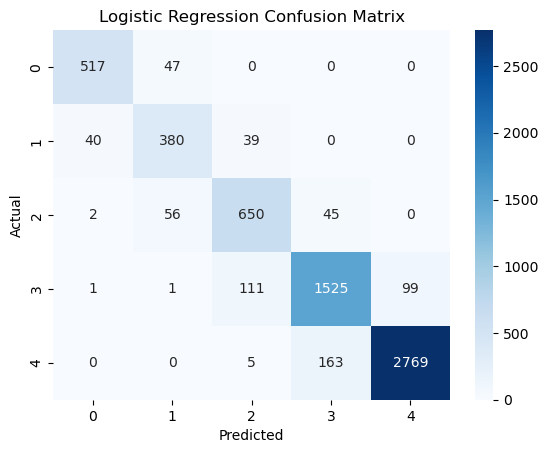

In [16]:
llfrom sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD



# ------------------ DIMENSIONALITY REDUCTION ------------------
svd = TruncatedSVD(n_components=50)
X_train_reduced = svd.fit_transform(X_train_scaled)
X_test_reduced = svd.transform(X_test_scaled)

# ------------------ MODEL TRAINING ------------------
logreg = LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000)
logreg.fit(X_train_reduced, y_train)

# ------------------ CROSS-VALIDATION ------------------
scores = cross_val_score(logreg, X_train_reduced, y_train, cv=5)
print("Cross-validation accuracy (mean):", scores.mean())

# ------------------ EVALUATION ------------------
y_pred = logreg.predict(X_test_reduced)
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [152]:
# Reset index of your original DataFrame to make sure alignment is clean
df_reset = df.reset_index(drop=True)

# X_test was created after dropping columns, so its index is different.
# But train_test_split preserves row order in .index.
# We get the indexes of X_test relative to df_reset
test_idx = X_test.index

# Create DataFrame of the original rows used in X_test
original_test_rows = df_reset.loc[test_idx].copy()

# Add Actual and Predicted columns
original_test_rows["Actual"] = y_test.values
original_test_rows["Predicted"] = y_pred

# Save to CSV
original_test_rows.to_csv("logistic_regression_predictions_with_metadata.csv", index=False)

print(" logistic_regression_predictions_with_metadata.csv")


 logistic_regression_predictions_with_metadata.csv


### Random forest


--- Random Forest ---
              precision    recall  f1-score   support

           1       0.91      0.59      0.72       564
           2       0.83      0.34      0.49       459
           3       0.77      0.79      0.78       753
           4       0.80      1.00      0.89      1737
           5       1.00      1.00      1.00      2937

    accuracy                           0.89      6450
   macro avg       0.86      0.75      0.77      6450
weighted avg       0.90      0.89      0.88      6450



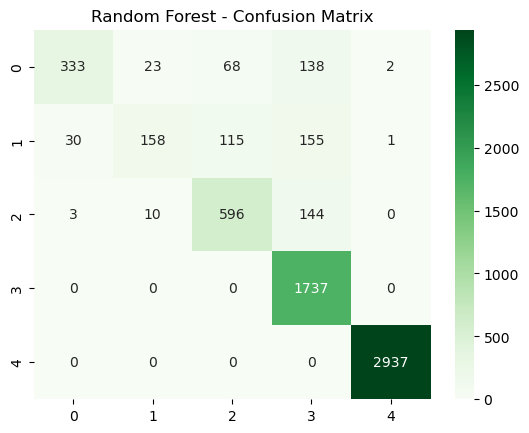

In [191]:
# ------------------ RANDOM FOREST ------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("random forest89.png")
plt.show()


--- Random Forest (Regularized) ---
              precision    recall  f1-score   support

           1       0.87      0.96      0.91       564
           2       0.83      0.80      0.81       459
           3       0.81      0.84      0.82       753
           4       0.91      0.85      0.87      1737
           5       0.95      0.96      0.96      2937

    accuracy                           0.91      6450
   macro avg       0.87      0.88      0.88      6450
weighted avg       0.91      0.91      0.91      6450



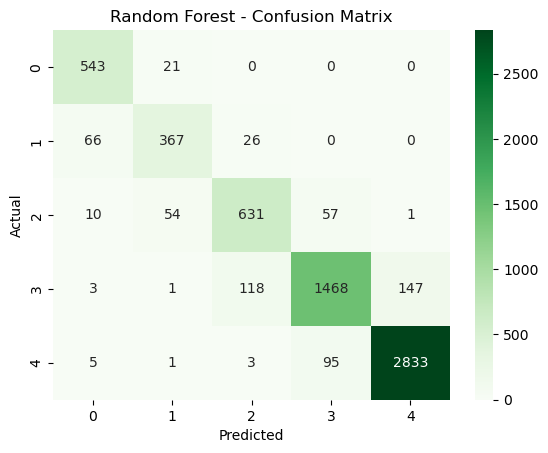

In [176]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Dimensionality reduction
svd = TruncatedSVD(n_components=100)
X_train_reduced = svd.fit_transform(X_train)
X_test_reduced = svd.transform(X_test)

# Feature selection
selector_model = RandomForestClassifier(n_estimators=50, random_state=42)
selector_model.fit(X_train_reduced, y_train)

selector = SelectFromModel(selector_model, threshold="median")
X_train_sel = selector.transform(X_train_reduced)
X_test_sel = selector.transform(X_test_reduced)

# Random Forest with regularization
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    max_samples=0.7,
    random_state=42
)
rf.fit(X_train_sel, y_train)
y_pred_rf = rf.predict(X_test_sel)

print("\n--- Random Forest (Regularized) ---")
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("random forest.png")
plt.show()


## SHAP

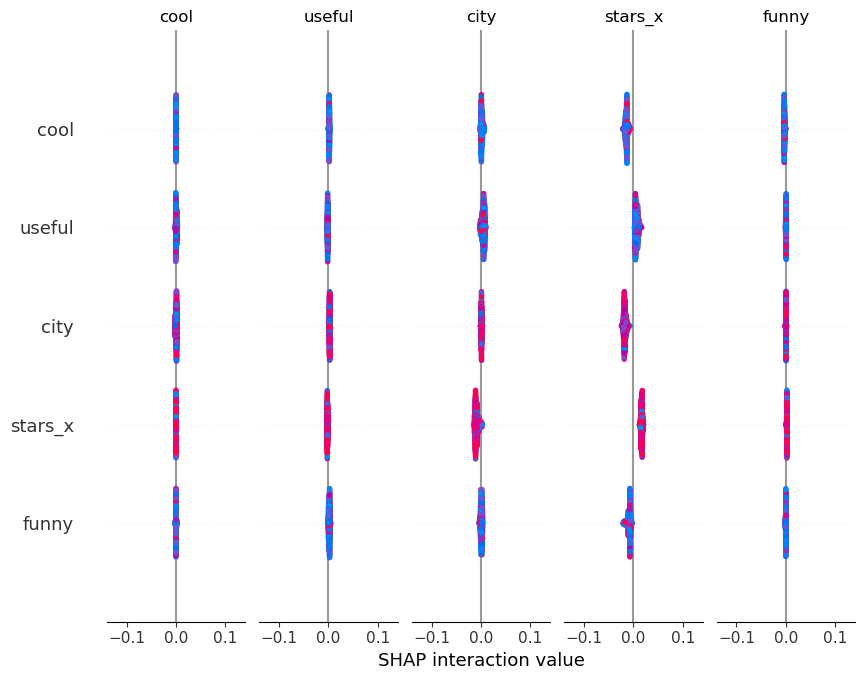

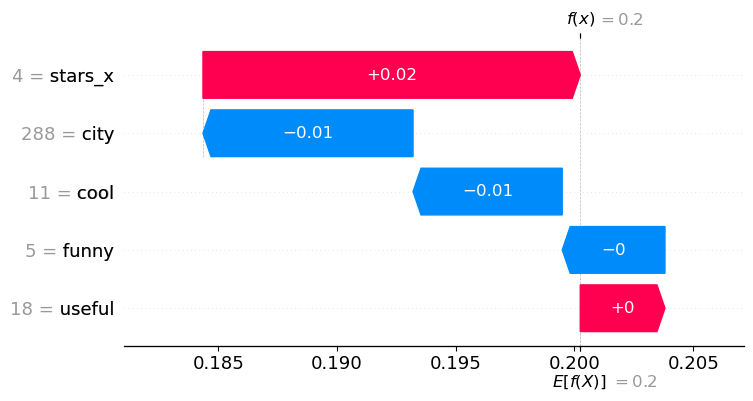

In [81]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# If you have a big test set, sample to save time
X_shap_sample = X_test if X_test.shape[0] <= 1000 else X_test[:1000]

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap_sample, check_additivity=False)

# ------------------ GLOBAL FEATURE IMPORTANCE ------------------
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns,
    show=True,
    
)

# ------------------ LOCAL EXPLANATION FOR FIRST SAMPLE ------------------
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_shap_sample.iloc[0],
        feature_names=X.columns
    )
)


In [124]:

# ----------------- Export Predictions -----------------
# Reset the index of the original DataFrame
df_reset = df.reset_index(drop=True)

# Get original test rows using stored indices
original_test_rows = df_reset.loc[test_idx].copy()

# Add Actual and Predicted columns
original_test_rows["Actual"] = y_test.values
original_test_rows["Predicted_RF"] = y_pred_rf

# Save to CSV
output_filename = "random_forest_predictions_with_metadata.csv"
original_test_rows.to_csv(output_filename, index=False)

print(f"Random Forest predictions saved to {output_filename}")


Random Forest predictions saved to random_forest_predictions_with_metadata.csv


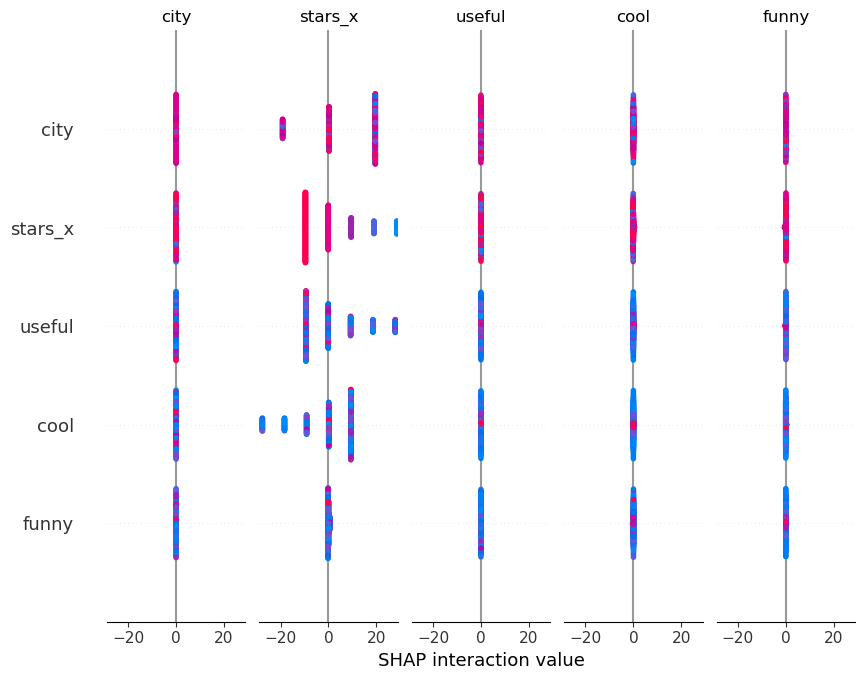

In [60]:
import shap

# 1. Fit model on scaled NumPy arrays
logreg.fit(X_train_scaled, y_train)

# 2. Create explainer with scaled NumPy arrays
explainer_log = shap.LinearExplainer(logreg, X_train_scaled)

# 3. Sample NUMPY rows
idx = np.random.choice(X_test_scaled.shape[0], size=500, replace=False)
sample_X = X_test_scaled[idx, :]

# 4. Compute SHAP values
shap_values = explainer_log.shap_values(sample_X)

# 5. Plot summary (without feature names)
shap.summary_plot(shap_values, sample_X, feature_names = X_train.columns)
